In [1]:
# Import PyTorch for tensor operations and GPU support
import torch

# Install essential libraries for efficient fine-tuning
# --no-deps avoids installing unnecessary dependencies
# xformers: memory-efficient attention
# trl: Transformer Reinforcement Learning (for training with prompts)
# peft: Parameter-Efficient Fine-Tuning (LoRA, etc.)
# accelerate: simplifies distributed training
# bitsandbytes: enables 4-bit quantizatio
!pip install --no-deps xformers trl peft accelerate bitsandbytes

# Install Unsloth directly from GitHub (optimized for faster training and lower memory)
# [colab-new] flag is specific for Google Colab environment
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-g9fvsk24/unsloth_c7584e374b644794babc9e57c8411f45
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-g9fvsk24/unsloth_c7584e374b644794babc9e57c8411f45
  Resolved https://github.com/unslothai/unsloth.git to commit 4f9c8321a2136e62fd86fe722a544afd534334a5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 34.7 MB/s eta 0:00:00


In [2]:
# Import Unsloth's optimized model loader for faster training and lower memory usage
from unsloth import FastLanguageModel
import torch


# Load the pre-trained TinyLlama model in 4-bit quantized format
# This reduces memory usage significantly (from ~4GB to ~1GB VRAM)
# - model_name: TinyLlama already pre-quantized by Unsloth (4-bit)
# - max_seq_length: maximum context length (2048 tokens is good for FAQ)
# - load_in_4bit: enables 4-bit quantization for memory efficiency
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/tinyllama-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/762M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/948 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

Unsloth: Will load unsloth/tinyllama-bnb-4bit as a legacy tokenizer.


In [3]:
# Suppress warning messages to keep output clean
import warnings
warnings.filterwarnings('ignore')
import logging
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# Enable inference mode (disables dropout and optimizes for generation)
FastLanguageModel.for_inference(model)

# Define the same test questions to compare base vs fine-tuned model
questions_to_test = [
    "What are houses in Africa called?",
    "How much will Xiaomi Mi Note-10-lite cost?"
]

# Generate responses from the base model BEFORE fine-tuning
print(" Generating responses from BASE MODEL (BEFORE Training)... (Please wait)\n")
print("*" * 60 + "\n")

for i, q in enumerate(questions_to_test, 1):
    print(f"🔹 Question ({i}):")
    print(f"[Question]: {q}")
    print("-" * 40)

     # Prompt template matching the fine-tuning format
    # This ensures the model understands it's an instruction-following task
    prompt = f"Below is an instruction that describes a task, paired with an input that provides further context. Write a direct, concise, and factual response in English.\n\n### Instruction:\n{q}\n\n### Input:\n\n\n### Response:\n"


    # Tokenize the prompt and move to GPU
    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")

    # Generate response with deterministic settings
    # max_new_tokens: limit response length
    #  do_sample=False: greedy decoding (most predictable)
    # repetition_penalty=1.2: discourages repeating words
    # pad_token_id: set to eos_token to avoid warnings
    outputs = model.generate(
        **inputs,
        max_new_tokens = 50,
        do_sample = False,
        repetition_penalty = 1.2,
        pad_token_id = tokenizer.eos_token_id
    )

     # Decode the generated tokens back to text
    text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

     # Extract only the response part
    if "### Response:" in text:
        final_answer = text.split("### Response:")[1].strip()
    else:
        final_answer = text.strip()

    # Remove any extra content
    final_answer = final_answer.split("###")[0].strip()

    print(f"[Base Model Answer]: {final_answer}\n")
    print("=" * 60 + "\n")

 Generating responses from BASE MODEL (BEFORE Training)... (Please wait)

************************************************************

🔹 Question (1):
[Question]: What are houses in Africa called?
----------------------------------------
[Base Model Answer]: Houses in Africa are called ________.


🔹 Question (2):
[Question]: How much will Xiaomi Mi Note-10-lite cost?
----------------------------------------
[Base Model Answer]: Xiaomi Mi Note-10-lite is a 6.43" (162.5mm) display smartphone with a resolution of 720 x 1560 pixels at 39




In [4]:
# Import pandas for data manipulation and datasets for Hugging Face Dataset forma
import pandas as pd
from datasets import Dataset


# Load the preprocessed dataset (Parquet format is efficient for large data)
# Note: This is likely a sample file from the 21M records after EMR preprocessing
# The full dataset would be loaded from S3 in production
df = pd.read_parquet("part_00001_21c5af0d_8ada_49e5_81be_093dc19d5a64_c000_snappy.parquet")

# Convert pandas DataFrame to Hugging Face Dataset object
# This format is optimized for use with transformers library
dataset = Dataset.from_pandas(df)
print("Data loaded successfully!")

Data loaded successfully!


In [5]:
# Display all column names in the dataset
# This helps verify the data structure before fine-tuning
# Expected columns: 'instruction', 'response', or similar (e.g., 'question', 'answer')
print(dataset.column_names)

['answer', 'id', 'origin', 'question', 'question_type', 'topic', 'url']


In [6]:
# Define the prompt template in Alpaca format (standard instruction-following format)
# This template tells the model how to interpret the task:
# - Instruction: the user's question
# - Input: optional context (left empty in our case)
# - Response: the expected answer (used during training
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

# Function to format each example into the prompt template
# This converts raw (question, answer) pairs into a single text field for training
def formatting_prompts_func(examples):
    # Extract questions and answers from dataset columns
    questions = examples["question"]
    answers = examples["answer"]

    texts = []
    # Iterate through each question-answer pair
    for question, answer in zip(questions, answers):
        # Format: Instruction = question, Input = empty string, Response = answer
        text = alpaca_prompt.format(question, "", answer)
        texts.append(text)
    return { "text" : texts, }

# Apply the formatting function to the entire dataset (batched for efficiency)
# batched=True processes multiple examples at once (faster)
dataset = dataset.map(formatting_prompts_func, batched = True,)

print("Data formatted successfully! Ready for training ")

Map:   0%|          | 0/6291 [00:00<?, ? examples/s]

Data formatted successfully! Ready for training 


### Fine-Tuning Hyperparameters

| Hyperparameter | Value | Description |
| :--- | :--- | :--- |
| **Learning Rate** | 2e-4 | Standard learning rate for LoRA convergence |
| **Batch Size** | 2 | Per device batch size to avoid OOM on Colab T4 |
| **Max Steps** | 300 | Increased to 300 to prevent underfitting |
| **Optimizer** | adamw_8bit | Memory-efficient optimizer |
| **LoRA Rank (r)** | 16 | Rank dimension for low-rank matrices |
| **LoRA Alpha** | 16 | Scaling factor for LoRA updates |


In [7]:
# Import SFTTrainer for supervised fine-tuning and TrainingArguments for hyperparameters
from trl import SFTTrainer
from transformers import TrainingArguments

# Apply LoRA (Low-Rank Adaptation) to the base model
# This adds trainable adapter layers while keeping base model frozen
# - r = 16: rank of LoRA matrices (higher = more capacity, more memory)
# - target_modules: which attention layers to apply LoRA to (Q, K, V, O projections)
# - lora_alpha = 16: scaling factor (typically same as r for balanced performance)
# - lora_dropout = 0: no dropout (sufficient for smaller models like TinyLlama)
# - bias = "none": don't train bias parameters (saves memory)
model = FastLanguageModel.get_peft_model(model, r = 16, target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"], lora_alpha = 16, lora_dropout = 0, bias = "none")

# Initialize the SFT Trainer for supervised fine-tuning
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",    # Column containing formatted prompts
    max_seq_length = 2048,         # Maximum sequence length (matches model's limit)
    args = TrainingArguments(
        per_device_train_batch_size = 2,                    # Batch size per GPU (lower = less memory)
        gradient_accumulation_steps = 4,                    # Simulate larger batch: 2 * 4 = effective batch size 8
        max_steps = 300,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        logging_steps = 10,                                 # Log loss every 10 steps
        output_dir = "outputs",
    ),
)

# Start the training process
# This will show a progress bar and training loss
trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/6291 [00:00<?, ? examples/s]

{'loss': '2.606', 'grad_norm': 'nan', 'learning_rate': '0.000194', 'epoch': '0.01271'}
{'loss': '2.537', 'grad_norm': 'nan', 'learning_rate': '0.0001873', 'epoch': '0.02543'}
{'loss': '2.628', 'grad_norm': '0.0008803', 'learning_rate': '0.0001807', 'epoch': '0.03814'}
{'loss': '2.595', 'grad_norm': '0.0003453', 'learning_rate': '0.000174', 'epoch': '0.05086'}
{'loss': '2.613', 'grad_norm': '0.0002441', 'learning_rate': '0.0001673', 'epoch': '0.06357'}
{'loss': '2.613', 'grad_norm': '0', 'learning_rate': '0.0001607', 'epoch': '0.07629'}
{'loss': '2.615', 'grad_norm': '0.001315', 'learning_rate': '0.000154', 'epoch': '0.089'}
{'loss': '2.694', 'grad_norm': '0', 'learning_rate': '0.0001473', 'epoch': '0.1017'}
{'loss': '2.632', 'grad_norm': '0.000598', 'learning_rate': '0.0001407', 'epoch': '0.1144'}
{'loss': '2.704', 'grad_norm': '0', 'learning_rate': '0.000134', 'epoch': '0.1271'}
{'loss': '2.692', 'grad_norm': '0.0009766', 'learning_rate': '0.0001273', 'epoch': '0.1399'}
{'loss': '2.66

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

{'train_runtime': '340.8', 'train_samples_per_second': '7.043', 'train_steps_per_second': '0.88', 'train_loss': '2.621', 'epoch': '0.3814'}


TrainOutput(global_step=300, training_loss=2.620912094116211, metrics={'train_runtime': 340.755, 'train_samples_per_second': 7.043, 'train_steps_per_second': 0.88, 'train_loss': 2.620912094116211, 'epoch': 0.3814367450731087})

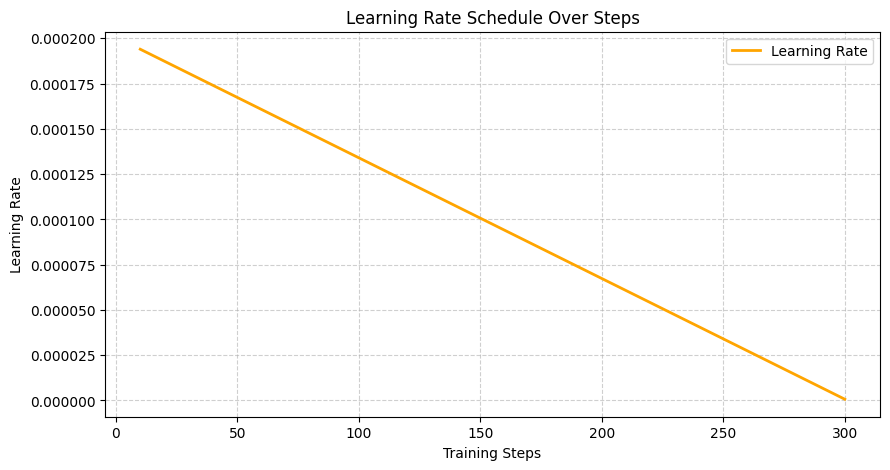

In [8]:
# Import matplotlib for plotting graphs and charts
import matplotlib.pyplot as plt

# Access the training history stored in the trainer object
# This contains all logged metrics during training
history = trainer.state.log_history

# Filter the history to extract learning rate values and their corresponding steps
# Each log entry that contains 'learning_rate' has:
#   - 'step': the training step number at which the metric was logged
#   - 'learning_rate': the learning rate value at that step
steps = [entry['step'] for entry in history if 'learning_rate' in entry]
lr_values = [entry['learning_rate'] for entry in history if 'learning_rate' in entry]

# Plot learning rate on Y-axis against training steps on X-axis
# - 'orange' color for visibility
# - linewidth=2 makes the line thicker and easier to rea
plt.figure(figsize=(10, 5))
plt.plot(steps, lr_values, label='Learning Rate', color='orange', linewidth=2)

#Add formatting
plt.title('Learning Rate Schedule Over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

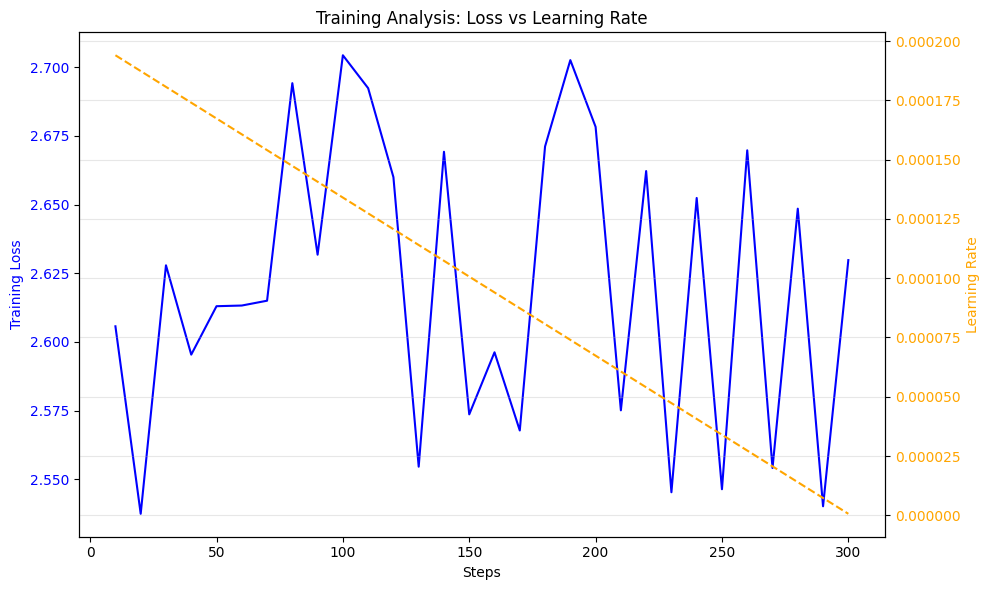

In [13]:
# Import matplotlib for plotting graphs and charts
import matplotlib.pyplot as plt


# Access the training history stored in the trainer object
history = trainer.state.log_history

# Extract loss values and their corresponding steps
# Filters entries that contain 'loss' key
steps = [x['step'] for x in history if 'loss' in x]
loss = [x['loss'] for x in history if 'loss' in x]

# Extract learning rate values (same steps approximately)
# Filters entries that contain 'learning_rate' key
lr = [x['learning_rate'] for x in history if 'learning_rate' in x]


# Create a figure and a primary axis (ax1)
# figsize=(10, 6): 10 inches wide, 6 inches tall
fig, ax1 = plt.subplots(figsize=(10, 6))


# Label for X-axis (shared between both axes)
ax1.set_xlabel('Steps')

# Label for Y-axis on the left side (blue)
ax1.set_ylabel('Training Loss', color='blue')

# Plot loss on the left axis with blue color
ax1.plot(steps, loss, color='blue', label='Loss')

# Set the tick color on left Y-axis to match the line color (blue)
ax1.tick_params(axis='y', labelcolor='blue')


# Create a secondary axis (twinx) that shares the same X-axis
ax2 = ax1.twinx()

# Label for Y-axis on the right side (orange)
ax2.set_ylabel('Learning Rate', color='orange')

# Plot learning rate on the right axis with orange color
# linestyle='--' creates a dashed line to distinguish from loss
ax2.plot(steps, lr, color='orange', label='Learning Rate', linestyle='--')

# Set the tick color on right Y-axis to match the line color (orange)
ax2.tick_params(axis='y', labelcolor='orange')


# Add a title to the graph
plt.title('Training Analysis: Loss vs Learning Rate')

# Add a grid with low opacity (30%) for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent labels from overlapping
fig.tight_layout()

# Render and show the combined plot
plt.show()

In [15]:
# Randomly sample one question from the 'question' column of the DataFrame
# .sample(1) selects 1 random row
# .iloc[0] extracts the value from that row (returns a string)
random_question = df['question'].sample(1).iloc[0]

# Print the randomly selected question to the console
# The Arabic text says: "The random question is: {question}"
print(f"The random question is  : {random_question}")

The random question is  : What are the insurance charges for Hero HF 100 in Doda?


In [18]:
# Suppress warning messages to keep output clean
import warnings
warnings.filterwarnings('ignore')
import logging
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# Enable inference mode for faster generation and lower memory usage
# This disables dropout and optimizes the model for prediction
FastLanguageModel.for_inference(model)

# Define the same test questions used for the base model
# This allows fair comparison between base and fine-tuned model
questions_to_test = [
    "What are houses in Africa called?",
    "How much will Xiaomi Mi Note-10-lite cost?"
]

print(" Generating specific answers from FINE-TUNED MODEL... (Please wait)\n")
print("*" * 60 + "\n")

# Iterate through each question and generate an answer
for i, q in enumerate(questions_to_test, 1):
    print(f"🔹 Question ({i}):")
    print(f"[Question]: {q}")
    print("-" * 40)

    # Use the SAME prompt template as the base model for fair comparison
    # The template asks for a direct, concise, factual response in English
    prompt = f"Below is an instruction that describes a task, paired with an input that provides further context. Write a direct, concise, and factual response in English.\n\n### Instruction:\n{q}\n\n### Input:\n\n\n### Response:\n"

    # Tokenize the prompt and move to GPU for faster inference
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    # Generate response with deterministic settings (same as base model)
    # - max_new_tokens=50: keep responses brief and focused
    # - do_sample=False: greedy decoding (no randomness, same answer every time)
    # - repetition_penalty=1.2: discourages repeating words or phrases
    # - pad_token_id: set to eos_token to avoid warnings
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decode the generated tokens back to human-readable text
    text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    # Extract only the response part (after "### Response:")
    if "### Response:" in text:
        final_answer = text.split("### Response:")[1].strip()
    else:
        final_answer = text.strip()

    # Remove any extra content (e.g., if another "###" appears)
    final_answer = final_answer.split("###")[0].strip()

    # Print the final answer from the fine-tuned model
    print(f"[Fine-Tuned Model Answer]: {final_answer}\n")
    print("=" * 60 + "\n")

 Generating specific answers from FINE-TUNED MODEL... (Please wait)

************************************************************

🔹 Question (1):
[Question]: What are houses in Africa called?
----------------------------------------
[Fine-Tuned Model Answer]: Africa has many different types of houses. The most common type of house found on the African continent is the mud hut. This type of house is made from dirt or clay mixed together with straw or grass. It can be


🔹 Question (2):
[Question]: How much will Xiaomi Mi Note-10-lite cost?
----------------------------------------
[Fine-Tuned Model Answer]: Xiaomi Mi Note-10-lite is a 6.43" (162.5mm) display smartphone with a 8GB RAM, 128GB ROM, and a 4


